# **Iris Flower Classification**

In [ ]:
import csv
import numpy as np
import math

In [ ]:
file = open("/content/Iris.csv", "r")
dataset = csv.reader(file)
dataset = np.array(list(dataset))
dataset = np.delete(dataset, 0, 0)
dataset = np.delete(dataset, 0, 1)
file.close()

trainingSet = dataset[:149]
testingSet = dataset[149:]

In [ ]:
def computeDistance(dataPoint1, dataPoint2):
    result = 0
    for i in range(4):
        result += (float(dataPoint1[i]) - float(dataPoint2[i])) ** 2
    return math.sqrt(result)

In [ ]:
def computeKnearestNeighbors(trainingSet, item, k):
    distances = []
    for dataPoint in trainingSet:
        distances.append(
            {
                "label": dataPoint[-1],
                "value": computeDistance(item, dataPoint)
            }
        )
        distances.sort(key= lambda x: x["value"])
        labels = [item["label"] for item in distances]
        return labels[:k]

In [ ]:
def voteTheDistance(array):
    labels = set(array)
    result = ""
    max0ccur = 0
    for label in labels:
        num = array.count(label)
        if(num > max0ccur):
            max0ccur = num
            result = label

    return result

In [ ]:
k = 5
# print(testingSet)
for item in testingSet:
    knn = computeKnearestNeighbors(trainingSet, item, k)
    result = voteTheDistance(knn)
    print("GT = ", item[-1], ", Prediction: = ", result)

GT =  Iris-virginica , Prediction: =  Iris-setosa


# **How to select K in K-NN**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [ ]:
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"

names = ['sepal-length', 'sepal-width', 'petal-length', 'petal-width', 'Class']

# Read the dataset in
dataset = pd.read_csv(url, names=names)
dataset

,sepal-length,sepal-width,petal-length,petal-width,Class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [ ]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, 4].values

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1)

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)

X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors=5)
classifier.fit(X_train, y_train)

KNeighborsClassifier()

In [ ]:
y_pred = classifier.predict(X_test)
y_pred != y_test

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False,  True, False, False, False, False,
       False, False, False])

In [ ]:
from sklearn.metrics import accuracy_score, classification_report
print(round(accuracy_score(y_test, y_pred),2))

0.97


In [ ]:
from sklearn.metrics import accuracy_score, classification_report
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        11
Iris-versicolor       1.00      0.92      0.96        13
 Iris-virginica       0.86      1.00      0.92         6

       accuracy                           0.97        30
      macro avg       0.95      0.97      0.96        30
   weighted avg       0.97      0.97      0.97        30



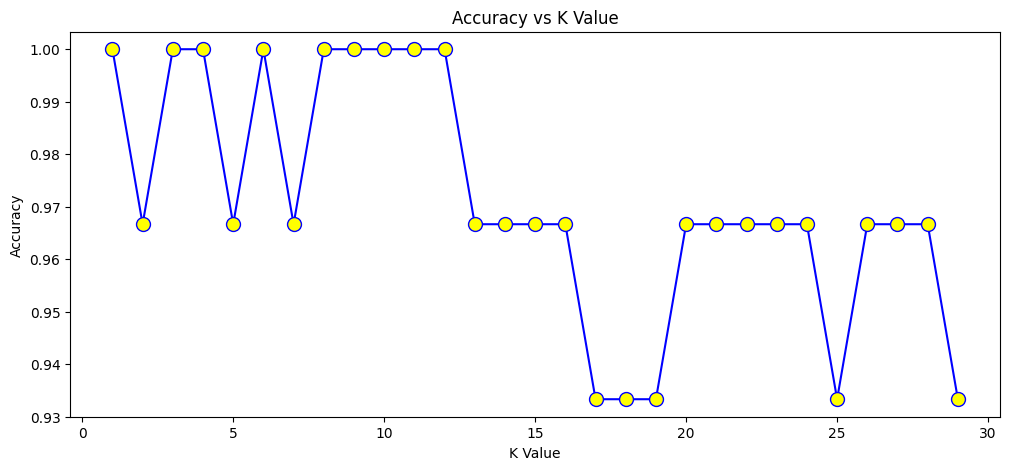

In [ ]:
error = []
# Calculating accuracy for K-values between 1 and 30
for i in range(1, 30):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error.append(accuracy_score(pred_i, y_test))

plt.figure(figsize=(12, 5))
plt.plot(range(1, 30), error, color='blue', marker='o',
         markerfacecolor='yellow', markersize=10)
plt.title('Accuracy vs K Value')
plt.xlabel('K Value')
plt.ylabel('Accuracy');

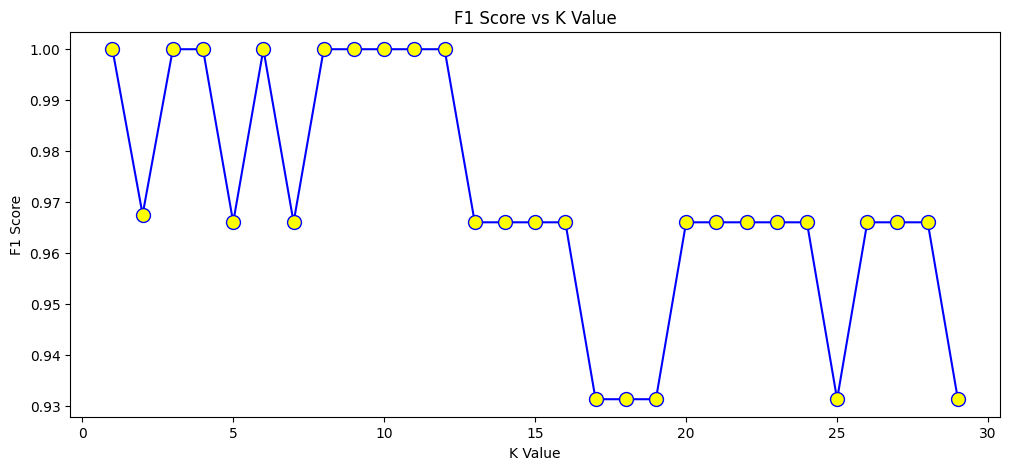

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score
f1_scores = []
# Calculating accuracy for K-values between 1 and 30
for i in range(1, 30):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    f1_scores.append(f1_score(pred_i, y_test, average='weighted'))

plt.figure(figsize=(12, 5))
plt.plot(range(1, 30), f1_scores, color='blue', marker='o',
         markerfacecolor='yellow', markersize=10)
plt.title('F1 Score vs K Value')
plt.xlabel('K Value')
plt.ylabel('F1 Score');

# **Problem with K odd and even**

In [ ]:
#Required Libraries
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KNeighborsClassifier
import warnings
warnings.filterwarnings('ignore')

In [ ]:
penguin= pd.read_csv("/content/penguins.csv")
penguin.head(2)

,species,island,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181,3750,MALE
1,Adelie,Torgersen,39.5,17.4,186,3800,FEMALE


In [ ]:
x = penguin[['culmen_length_mm','culmen_depth_mm','flipper_length_mm','body_mass_g']]
y = penguin[['species']]

In [ ]:
np.random.seed(0)
X_train, X_test, y_train, y_test = train_test_split(x, y,test_size = 0.2, stratify = y,random_state = 4)

In [ ]:
X_test = np.array(X_test)
X_train = np.array(X_train)
y_train = np.array(y_train)
y_test = np.array(y_test)

In [ ]:
def knn_modified(X_train,y_train,X_test,k):
    pred = []
    for j in range(len(X_test)):
        distance = []
        min_dist = math.inf
        for i in range(len(X_train)):
            eulidean_distance = np.sqrt(np.sum((X_test[j,] - X_train[i,])**2))
            if eulidean_distance < min_dist:
                distance.append((eulidean_distance, i))
            else:
                continue

        #Sort the list by distance
        distance.sort()

        #Get the row index of its nearest neighbour
        neighbours = []

        for j in range(k):
            neighbours.append(distance[j][1])

        #Append the actual target in a list
        target = []
        for l in range(k):
            target.append(np.array(y_train)[neighbours[l]][0])

        #Create a function for counting
        count = {}
        for t in target:
            count[t] = count.get(t,0) + 1

        #Create a list with (value, key) pair
        pairs = []
        for key in count:
            pairs.append((count[key], key))

        #Sort the pair and get the most occurring word
        pairs.sort(reverse=True)
        if k%2 == 0:
            even = []
            for i in range(0,len(pairs)):
                if pairs[0][0] == pairs[i][0]:
                    even.append(pairs[i][1])
            #print('Arranging in decreasing order: ',even)
            for j in neighbours:
                if y_train[j][0] in even:
                    pred.append(y_train[j][0])
                    #print('Value with the least distance classifies: ',y_train[j][0])
                    #print('Picking classifier based on least distance: ',y_train[j][0])
                    break
                else:
                    pred.append(pairs[0][1])
                    break
        else:
            pred.append(pairs[0][1])

    return(pred)

In [ ]:
n = 2
pred = knn_modified(X_train,y_train,X_test,k=n)
neighbors = list(range(1,11))
scores = []

for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k,algorithm='brute', metric='euclidean')
    pred1 = knn.fit(X_train, y_train)
    pred = pred1.predict(X_test)
    accuracy =  accuracy_score(y_test, pred)
    scores.append(accuracy)

scores1 = []
neighbors = list(range(1,11))
for i in neighbors:
    pred = knn_modified(X_train,y_train,X_test,k=i)
    accuracy =  accuracy_score(y_test, pred)
    scores1.append(accuracy)

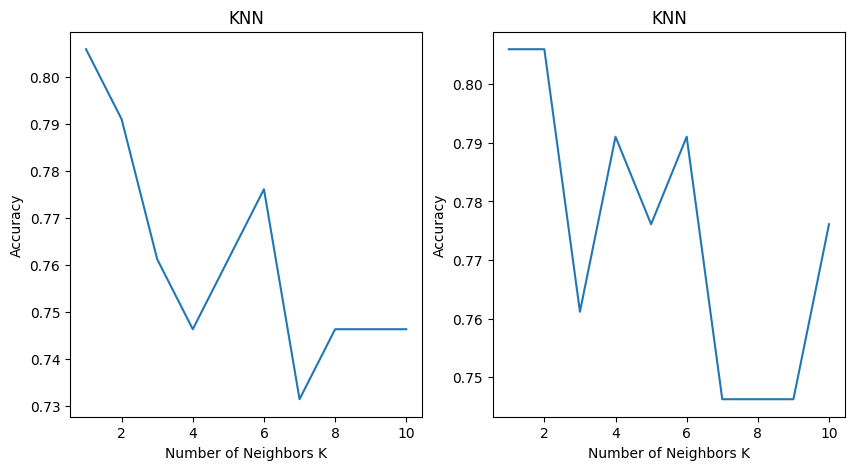

In [ ]:
MSE = [ x for x in scores]
plt.figure(figsize=(10, 5))
MSE1 = [ x for x in scores1]
plt.subplot(1,2,1)
plt.plot(neighbors, MSE)
plt.xlabel('Number of Neighbors K')
plt.ylabel('Accuracy')
plt.title('KNN')
plt.subplot(1,2,2)
plt.plot(neighbors, MSE1)
plt.xlabel('Number of Neighbors K')
plt.ylabel('Accuracy')
plt.title('KNN')
plt.show()

**UNIFORM WEIGHTS**

**DISTANCE WEIGHTS**

**USER-DEFINED WEIGHTS**

In [ ]:
from sklearn import datasets

dataset = datasets.load_iris()
X = dataset.data
y = dataset.target

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.5)

In [ ]:
# UNIFORM WEIGHTS
classifier = KNeighborsClassifier(n_neighbors=8, weights = 'uniform', p = 2)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

In [ ]:
print("accuracy %.2f%%"%(100*accuracy_score(y_test,y_pred)))
print(classification_report(y_test,y_pred))

accuracy 96.00%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       0.93      0.96      0.94        26
           2       0.96      0.93      0.94        27

    accuracy                           0.96        75
   macro avg       0.96      0.96      0.96        75
weighted avg       0.96      0.96      0.96        75



In [ ]:
# DISTANCE WEIGHTS
classifier = KNeighborsClassifier(n_neighbors=8, p = 2, weights="distance")
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

In [ ]:
print("accuracy %.2f%%"%(100*accuracy_score(y_test,y_pred)))
print(classification_report(y_test,y_pred))

accuracy 97.33%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       0.96      0.96      0.96        26
           2       0.96      0.96      0.96        27

    accuracy                           0.97        75
   macro avg       0.97      0.97      0.97        75
weighted avg       0.97      0.97      0.97        75



In [ ]:
# USE-DEFINED WEIGHTS
def customizeWeight(distances):
  sigma = 0.5
  return np.exp(-distances**2/sigma)

In [ ]:
classifier = KNeighborsClassifier(n_neighbors=4, p = 2, weights=customizeWeight)
classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)

In [ ]:
print("accuracy %.2f%%"%(100*accuracy_score(y_test,y_pred)))
print(classification_report(y_test,y_pred))

accuracy 94.67%
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        22
           1       0.89      0.96      0.93        26
           2       0.96      0.89      0.92        27

    accuracy                           0.95        75
   macro avg       0.95      0.95      0.95        75
weighted avg       0.95      0.95      0.95        75



# **KNN_KDTree**

In [ ]:
import pandas as pd
from sklearn.neighbors import KDTree

In [ ]:
df = pd.read_csv("https://bitbucket.org/zeerobug/material/raw/12301e73580ce6b623a7a6fd601c08549eed1c45/datasets/votes_skills_anon.csv", index_col=0)
df.head()

,SUID,univid,response
0,538.0,5c9e7a6834cda4f3677e662b,Internationality
1,2285.0,5c9e373c34cda4f3677e14ef,Practical relevance / professionalization
2,2285.0,5c9e7d8334cda4f3677e6b4f,Internationality
3,2285.0,5e84b8a01ead1a77be3bd3a8,Soft skills and digital literacy
4,2285.0,5c9e471734cda4f3677e2ed7,Internationality


In [ ]:
skills = df.groupby(["univid", "response"])["response"].count().reset_index(name='value')
skills.head()

,univid,response,value
0,5c9e345f34cda4f3677e1047,Academic excellence,10
1,5c9e345f34cda4f3677e1047,Internationality,24
2,5c9e345f34cda4f3677e1047,Practical relevance / professionalization,10
3,5c9e345f34cda4f3677e1047,Soft skills and digital literacy,7
4,5c9e345f34cda4f3677e1047,Specialization,18


In [ ]:
univSkills = skills.pivot_table(values="value", columns="response", index=["univid"])
univSkills.head()

response,Academic excellence,Internationality,Practical relevance / professionalization,Soft skills and digital literacy,Specialization
univid,,,,,
5c9e345f34cda4f3677e1047,10.0,24.0,10.0,7.0,18.0
5c9e349434cda4f3677e109f,5.0,10.0,12.0,9.0,15.0
5c9e34a834cda4f3677e10bd,8.0,10.0,8.0,6.0,8.0
5c9e34ae34cda4f3677e10c7,1.0,17.0,17.0,14.0,17.0
5c9e34d534cda4f3677e1107,10.0,11.0,15.0,10.0,24.0


In [ ]:
univSkills.sum(axis=1).head()

,0
univid,
5c9e345f34cda4f3677e1047,69.0
5c9e349434cda4f3677e109f,51.0
5c9e34a834cda4f3677e10bd,40.0
5c9e34ae34cda4f3677e10c7,66.0
5c9e34d534cda4f3677e1107,70.0


In [ ]:
univSkills = univSkills.div(univSkills.sum(axis=1), axis=0)
univSkills.fillna(0, inplace=True )
univSkills.head()

response,Academic excellence,Internationality,Practical relevance / professionalization,Soft skills and digital literacy,Specialization
univid,,,,,
5c9e345f34cda4f3677e1047,0.144928,0.347826,0.144928,0.101449,0.260870
5c9e349434cda4f3677e109f,0.098039,0.196078,0.235294,0.176471,0.294118
5c9e34a834cda4f3677e10bd,0.200000,0.250000,0.200000,0.150000,0.200000
5c9e34ae34cda4f3677e10c7,0.015152,0.257576,0.257576,0.212121,0.257576
5c9e34d534cda4f3677e1107,0.142857,0.157143,0.214286,0.142857,0.342857


In [ ]:
tree = KDTree(univSkills)
dist, ind = tree.query(univSkills[9:10], k=5)
data_u = univSkills.iloc[ind.tolist()[0]]
data_u.head()
data_u["Academic excellence"]

,Academic excellence
univid,
5c9e35b234cda4f3677e126b,0.047059
5c9e5b5e34cda4f3677e42fb,0.078125
5c9e3fc034cda4f3677e22e3,0.087500
5e8c879823d6684db014ea30,0.074074
5c9e7c4034cda4f3677e6937,0.075472
